# 02 — Preprocessing
**CFPB Consumer Complaint Classification** (Debt collection vs Credit card)

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
df = pd.read_csv('../data/complaints.csv')
print('Loaded shape:', df.shape)

Loaded shape: (114953, 16)


## 1. Drop unused columns

In [3]:
def drop_unused_columns(df):
    keep = ['Product', 'Sub-product', 'Issue', 'Consumer complaint narrative', 'State', 'Company']
    return df[keep].copy()

df = drop_unused_columns(df)
print('After dropping unused columns:', df.shape)
print(df.columns.tolist())

After dropping unused columns: (114953, 6)
['Product', 'Sub-product', 'Issue', 'Consumer complaint narrative', 'State', 'Company']


## 2. Fill null values in categorical columns with mode

In [4]:
def fill_categorical_nulls(df):
    cat_cols = ['Sub-product', 'Issue', 'State', 'Company']
    print('--- Before filling ---')
    print(df[cat_cols].isnull().sum())
    for col in cat_cols:
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
    print('\n--- After filling ---')
    print(df[cat_cols].isnull().sum())
    return df

df = fill_categorical_nulls(df)

--- Before filling ---
Sub-product      0
Issue            0
State          284
Company          0
dtype: int64

--- After filling ---


Sub-product    0
Issue          0
State          0
Company        0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3228\2653518669.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


## 3. Drop null narratives

In [5]:
def drop_null_narratives(df):
    before = len(df)
    df = df.dropna(subset=['Consumer complaint narrative']).copy()
    print(f'Dropped null narratives: {before} -> {len(df)} ({before - len(df)} removed)')
    return df

df = drop_null_narratives(df)

Dropped null narratives: 114953 -> 114953 (0 removed)


## 4. Remove duplicate narratives

In [6]:
def remove_duplicate_narratives(df):
    before = len(df)
    df = df.drop_duplicates(subset=['Consumer complaint narrative']).copy()
    print(f'Removed duplicates: {before} -> {len(df)} ({before - len(df)} removed)')
    return df

df = remove_duplicate_narratives(df)

Removed duplicates: 114953 -> 94274 (20679 removed)


## 5. Remove heavily redacted narratives (>50% XXXX)

In [7]:
def remove_redacted_heavy_narratives(df):
    before = len(df)
    def redaction_pct(text):
        words = str(text).split()
        if len(words) == 0:
            return 0
        return sum(1 for w in words if 'XXXX' in w.upper()) / len(words)
    mask = df['Consumer complaint narrative'].apply(redaction_pct) <= 0.5
    df = df[mask].copy()
    print(f'Removed redacted-heavy: {before} -> {len(df)} ({before - len(df)} removed)')
    return df

df = remove_redacted_heavy_narratives(df)

Removed redacted-heavy: 94274 -> 94130 (144 removed)


## 6. Clean narrative text

In [8]:
def clean_narrative_text(df):
    def clean(text):
        text = str(text).strip()
        text = re.sub(r'[#|]', ' ', text)        # remove markdown junk
        text = re.sub(r'\*{2,}', ' ', text)      # repeated asterisks
        text = re.sub(r'\s+', ' ', text).strip()  # collapse whitespace
        return text
    df['Consumer complaint narrative'] = df['Consumer complaint narrative'].apply(clean)
    print('Text cleaned.')
    return df

df = clean_narrative_text(df)
df['Consumer complaint narrative'].head(3)

Text cleaned.


1    charges unauthorized {$850.00}. none of charge...
2    I want to stress that I did not give written p...
3    XX/XX/2025 I applied for an American Express c...
Name: Consumer complaint narrative, dtype: object

## 7. Filter by length (drop narratives under 20 words)

In [9]:
# save word counts before filtering for comparison plot
df['word_count'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))
wc_before = df['word_count'].copy()

def filter_by_length(df, min_words=20):
    before = len(df)
    df = df[df['word_count'] >= min_words].copy()
    print(f'Filtered short narratives (<{min_words} words): {before} -> {len(df)} ({before - len(df)} removed)')
    return df

df = filter_by_length(df)

Filtered short narratives (<20 words): 94130 -> 91265 (2865 removed)


## 8. Before vs After cleaning — word count box plot

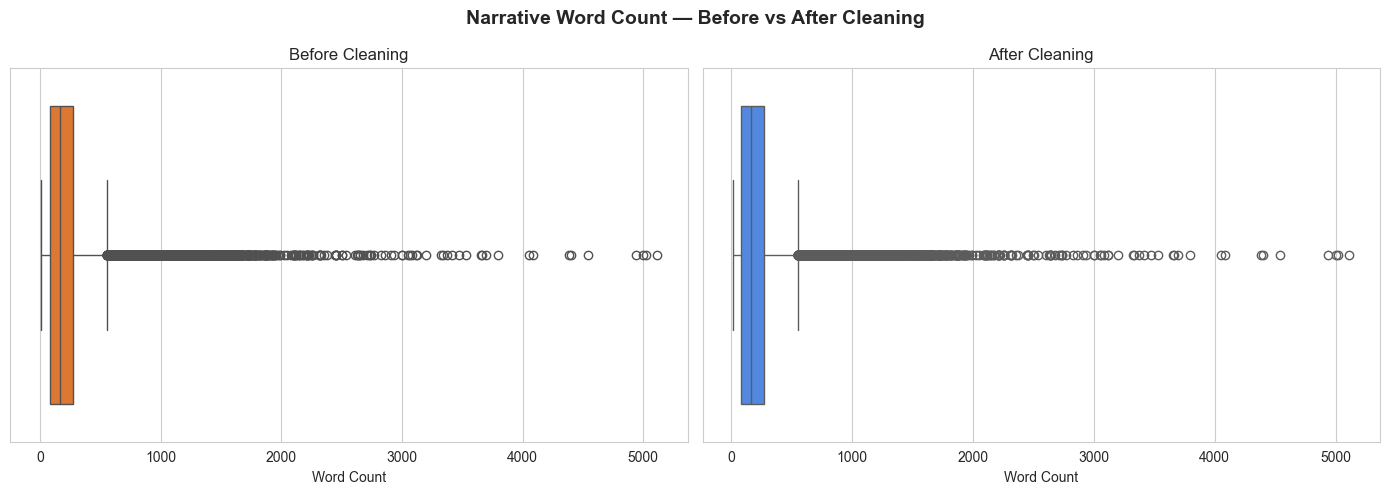

In [10]:
wc_after = df['word_count'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.boxplot(x=wc_before, color='#f97316', ax=axes[0])
axes[0].set_title('Before Cleaning')
axes[0].set_xlabel('Word Count')

sns.boxplot(x=wc_after, color='#3b82f6', ax=axes[1])
axes[1].set_title('After Cleaning')
axes[1].set_xlabel('Word Count')

fig.suptitle('Narrative Word Count — Before vs After Cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/wordcount_before_after_boxplot.png', dpi=150)
plt.show()

## 9. Balance and sample

In [11]:
print('Class counts before sampling:')
counts_before = df['Product'].value_counts()
print(counts_before)
print()

Class counts before sampling:
Product
Debt collection    57756
Credit card        33509
Name: count, dtype: int64



In [12]:
def balance_and_sample(df, total=8000):
    per_class = total // 2
    sampled = []
    for product in df['Product'].unique():
        subset = df[df['Product'] == product]
        n = min(per_class, len(subset))
        sampled.append(subset.sample(n=n, random_state=42))
    result = pd.concat(sampled).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Balanced sample: {len(result)} rows')
    print(result['Product'].value_counts())
    return result

df = balance_and_sample(df)

Balanced sample: 8000 rows
Product
Credit card        4000
Debt collection    4000
Name: count, dtype: int64


## 10. Before vs After sampling — class balance bar chart

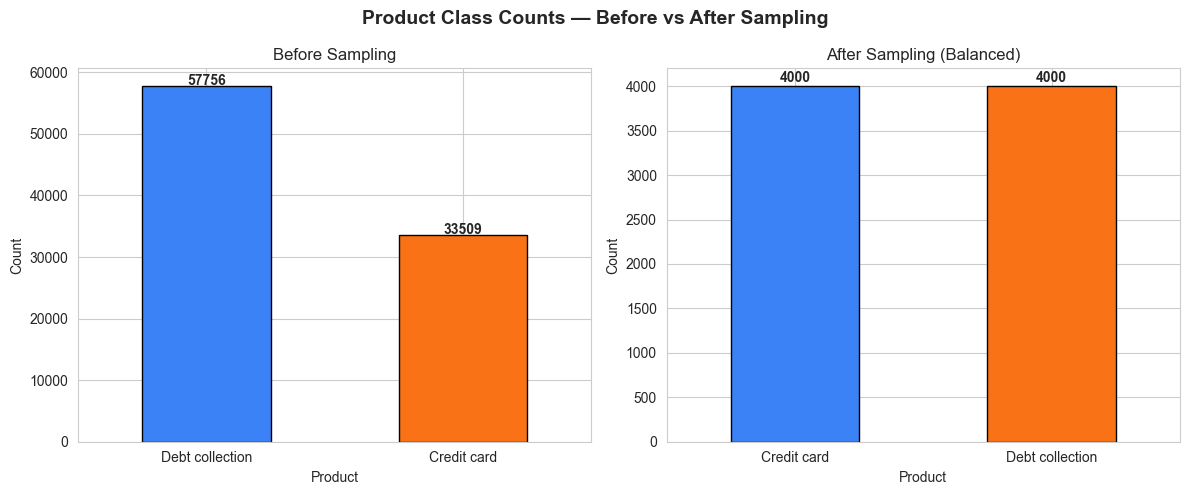

In [13]:
counts_after = df['Product'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3b82f6', '#f97316']

counts_before.plot(kind='bar', color=colors, edgecolor='black', ax=axes[0])
axes[0].set_title('Before Sampling')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts_before):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

counts_after.plot(kind='bar', color=colors, edgecolor='black', ax=axes[1])
axes[1].set_title('After Sampling (Balanced)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts_after):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

fig.suptitle('Product Class Counts — Before vs After Sampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/class_balance_before_after.png', dpi=150)
plt.show()

## 11. Train/test split

In [14]:
# drop helper column
df.drop(columns=['word_count'], inplace=True, errors='ignore')

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Product'], random_state=42)
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print()
print('Train class balance:')
print(train_df['Product'].value_counts())
print()
print('Test class balance:')
print(test_df['Product'].value_counts())

Train shape: (6400, 6)
Test shape: (1600, 6)

Train class balance:
Product
Debt collection    3200
Credit card        3200
Name: count, dtype: int64

Test class balance:
Product
Debt collection    800
Credit card        800
Name: count, dtype: int64


## 12. Save to /data

In [15]:
train_df.to_csv('../data/cleaned_train.csv', index=False)
test_df.to_csv('../data/cleaned_test.csv', index=False)
print('Saved cleaned_train.csv and cleaned_test.csv to /data')

Saved cleaned_train.csv and cleaned_test.csv to /data


## 13. Final summary

In [16]:
print('Final train shape:', train_df.shape)
print('Final test shape:', test_df.shape)
print()
print('Train class balance:')
print(train_df['Product'].value_counts())
print()
print('Sample of 5 cleaned rows:')
train_df[['Product', 'Consumer complaint narrative']].head(5)

Final train shape: (6400, 6)
Final test shape: (1600, 6)

Train class balance:
Product
Debt collection    3200
Credit card        3200
Name: count, dtype: int64

Sample of 5 cleaned rows:


,Product,Consumer complaint narrative
5149,Debt collection,I recently reviewed my credit report and disco...
7348,Credit card,XX/XX/XXXX : First noticed fraudulent activiti...
1079,Debt collection,"I received a letter from Jefferson Capital, LL..."
3156,Credit card,"On XX/XX/XXXX, I placed XXXX orders with XXXX ..."
5119,Credit card,I opened a Kohls credit card ( issued through ...
